In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from tqdm.notebook import tqdm,trange
from datetime import datetime

## Support

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, patches, embed_dim):
        super().__init__()
        self.d_k = embed_dim
        self.patches = patches
        pe = torch.zeros(patches, self.d_k)
        div = torch.exp(torch.arange(0, self.d_k, 2).float() * -(math.log(10000.0) / self.d_k))
        position = torch.arange(0, patches).float().unsqueeze(1)
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    
    def forward(self, x):
        return x + self.pe[:, :self.patches, :].detach()

In [3]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, h/p, w/p)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

In [4]:
class MultiheadAttention(nn.Module): # linear attention 
    def __init__(self,embed_dim,head):
        super().__init__()
        self.head = head
        self.head_dim = embed_dim // self.head 
        assert self.head * self.head_dim == embed_dim
        self.Q = nn.Linear(embed_dim,embed_dim)
        self.K = nn.Linear(embed_dim,embed_dim)
        self.V = nn.Linear(embed_dim,embed_dim)
        pass
    def feature_map(self,x):
        return F.gelu(x)
    def forward(self,x):
        # linear kernel
        B,L,E = x.size()
        q = self.Q(x).view(B,L,self.head,self.head_dim).transpose(2,1) # (32,156,200) = (32,156,4,50) = (32,4,156,50)
        k = self.K(x).view(B,L,self.head,self.head_dim).transpose(2,1) 
        v = self.V(x).view(B,L,self.head,self.head_dim).transpose(2,1) 
        k_t = self.feature_map(k.transpose(-1,-2))
        q = self.feature_map(q)
        kv = torch.matmul(k_t,v)
        num = torch.matmul(q,kv)
        z = k.sum(dim=2,keepdim=True).transpose(-1,-2)
        denom = torch.matmul(q,z)
        out = num / (denom + 1e-4)
        out = out.transpose(1, 2).reshape(B, L, E)
        return out

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads,mlp_ratio=4.0, qkv_bias=True, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(embed_dim)
        self.attn = MultiheadAttention(embed_dim, num_heads)
        self.norm2 = norm_layer(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(0.1)
        )
    
    def forward(self, x):
        # Self-attention
        attn_out= self.attn(self.norm1(x))
        x = x + attn_out # residual 1
        # MLP
        x = x + self.mlp(self.norm2(x)) # residual 2
        return x

def create_encoder_blocks(embed_dim, depth, num_heads):
    return nn.ModuleList([
        TransformerBlock(embed_dim, num_heads)
        for _ in range(depth)
    ])

def create_decoder_blocks(embed_dim, depth, num_heads):
    return nn.ModuleList([
        TransformerBlock(embed_dim, num_heads)
        for _ in range(depth)
    ])

In [6]:
class MaskedAutoencoderViT(nn.Module):
    def __init__(self, img_size=125, patch_size=5, in_chans=8,
                 encoder_embed_dim=200, encoder_depth=12, encoder_num_heads=4,
                 decoder_embed_dim=100, decoder_depth=8, decoder_num_heads=2,
                 mlp_ratio=4.,norm_pix_loss=False):
        
        super().__init__()
        
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, encoder_embed_dim)
        self.num_patches = self.patch_embed.num_patches
        # Encoder positional encoding (no cls token)
        self.encoder_pos_embed = PositionalEncoding(self.num_patches, encoder_embed_dim)
        # Encoder
        self.encoder_blocks = create_encoder_blocks(encoder_embed_dim, encoder_depth, encoder_num_heads)
        self.encoder_norm = nn.LayerNorm(encoder_embed_dim)
        # Decoder embedding
        self.encoder_to_decoder = nn.Linear(encoder_embed_dim, decoder_embed_dim, bias=True)
        # Decoder positional encoding (includes cls token position)
        self.decoder_pos_embed = PositionalEncoding(self.num_patches, decoder_embed_dim)
        # Decoder mask token and blocks
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim)) # 625 - 156 = 469
        self.decoder_blocks = create_decoder_blocks(decoder_embed_dim, decoder_depth, decoder_num_heads)
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        # Final prediction head
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True) # to take back to image 
        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights() # getting and Xavier weight 
    
    def initialize_weights(self):
        # Initialize encoder to decoder projection
        nn.init.xavier_uniform_(self.encoder_to_decoder.weight)
        nn.init.constant_(self.encoder_to_decoder.bias, 0)
        
        # Initialize mask token
        nn.init.normal_(self.mask_token, std=0.02)
        
        # Initialize decoder prediction head
        nn.init.xavier_uniform_(self.decoder_pred.weight)
        nn.init.constant_(self.decoder_pred.bias, 0)
        
        # Apply weight init to all layers
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def patchify(self, imgs):
        p = self.patch_embed.patch_size
        C = imgs.shape[1]  
        h, w = imgs.shape[2] // p, imgs.shape[3] // p
        x = imgs.reshape(shape=(imgs.shape[0], C, h, p, w, p))  # channels = 8
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * C))  
        return x

    
    def unpatchify(self, x): # to convert the patches = images 
        p = self.patch_embed.patch_size
        h, w = int(x.shape[1]**0.5), int(x.shape[1]**0.5)
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, h * p))
        return imgs
    
    def random_masking(self, x, mask_ratio): # random masking 
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1) # to get the location for un masking 
        
        ids_keep = ids_shuffle[:, :len_keep] # reducing the seq_len(num_patches) => 0.75 = 156
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x) # converting to patches 
        x = self.encoder_pos_embed(x) # positionally encoded 
        x_masked, mask, ids_restore = self.random_masking(x, mask_ratio) # random masking with uniform dist
        for block in self.encoder_blocks: # iteerating to depth of transformer blocks 
            x_masked = block(x_masked)
        x_encoded = self.encoder_norm(x_masked)
        
        return x_encoded, mask, ids_restore
    
    def forward_decoder(self, x_encoded, ids_restore):
        x_dec = self.encoder_to_decoder(x_encoded)  # [B, len_keep, decoder_dim]
        num_mask_tokens = ids_restore.shape[1] - x_dec.shape[1]  # Should be 625 - 156 = 469
        mask_tokens = self.mask_token.repeat(x_dec.shape[0], num_mask_tokens, 1) # here the 469 mask tokens are created 
        
        # Unshuffle: reconstruct full sequence
        x_ = torch.cat([x_dec, mask_tokens], dim=1)  # [B, 625, decoder_dim] # mask tokens are readded
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_dec.shape[2]))
        x_dec = self.decoder_pos_embed(x_)  # [B, 625, decoder_dim] = positional encoding 
        
        # Decoder transformer blocks
        for block in self.decoder_blocks:
            x_dec = block(x_dec)
        x_dec = self.decoder_norm(x_dec)
        
        # Final prediction
        x_pred = self.decoder_pred(x_dec)  # [B, 625, patch_size²×in_chans]
        
        return x_pred 

    
    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**0.5
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()  # Mean loss on masked patches
        return loss
    
    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask

In [7]:
# for this offical refrence are taken 
def mae_small(**kwargs):
    model = MaskedAutoencoderViT(
        encoder_embed_dim=200, encoder_depth=6, encoder_num_heads=4,
        decoder_embed_dim=100, decoder_depth=4, decoder_num_heads=2,
        mlp_ratio=4,**kwargs)
    return model
mae = mae_small

## Data importing and Transformation

In [8]:
import torch
import h5py
import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import numpy as np

class H5Dataset_fine(Dataset):
    def __init__(self, file_path, transform=None):
        self.file_path = file_path
        self.transform = transform

    def __getitem__(self, index):
        with h5py.File(self.file_path, "r") as f:
            jet_data = f["jet"][index]  # (H, W, 8)
            label = f["Y"][index]       # scalar label

        tensor = torch.from_numpy(jet_data).float()  # (H, W, 8)

        # Ensure (H, W, 8) → (8, H, W)
        if tensor.dim() == 3 and tensor.shape[-1] == 8:
            tensor = tensor.permute(2, 0, 1)  # (8, H, W)
        elif tensor.shape[0] != 8:
            raise ValueError(f"Expected 8‑channel input, got {tensor.shape}")

        label = torch.tensor(label, dtype=torch.float32)

        if self.transform is not None:
            tensor = self.transform(tensor)

        return tensor, label

    def __len__(self):
        with h5py.File(self.file_path, "r") as f:
            return len(f["jet"])

In [9]:
CH = 8
mean = [0.5] * CH
std  = [0.225] * CH  

finetune_transform = T.Compose([
    T.CenterCrop(125), 
    T.RandomHorizontalFlip(p=0.2),
    T.Normalize(mean=mean, std=std),
])

In [10]:
def create_dataloaders(h5_path, batch_size=16, val_split=0.2, num_workers=0, transform=None):
    full_dataset = H5Dataset_fine(h5_path, transform=transform)

    n_samples = len(full_dataset)
    n_val = int(n_samples * val_split)
    n_train = n_samples - n_val

    train_dataset, val_dataset = random_split(
        full_dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    print(f"Split: Train={n_train}, Val={n_val}")

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader, full_dataset

In [11]:
train_loader, val_loader, full_dataset = create_dataloaders(
    "/media/pvg/1CB89C4BB89C24F4/CERN_DATA/Dataset_Specific_labelled.h5",
    batch_size=16,
    val_split=0.2,
    num_workers=0,
    transform=finetune_transform,
)

for images, labels in train_loader:
    print(f"Batch shape: Images={images.shape}, Labels={labels.shape}")
    print(f"Labels: {labels[:5]}")
    break

Split: Train=8000, Val=2000
Batch shape: Images=torch.Size([16, 8, 125, 125]), Labels=torch.Size([16, 1])
Labels: tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.]])


## Model Building

In [12]:
class MAEEncoder(nn.Module):
    def __init__(self, pretrained_mae):
        super().__init__()
        self.patch_embed = pretrained_mae.patch_embed
        self.encoder_pos_embed = pretrained_mae.encoder_pos_embed
        self.encoder_blocks = pretrained_mae.encoder_blocks
        self.encoder_norm = pretrained_mae.encoder_norm
        self.num_patches = pretrained_mae.num_patches

    def forward_features(self, x):
        x = self.patch_embed(x)
        x = self.encoder_pos_embed(x)
        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)
        return x.mean(dim=1)

    def forward(self, x):
        return self.forward_features(x)

In [13]:
class ClassificationHead(nn.Module):
    def __init__(self, encoder_dim=200, num_classes=2):  
        super().__init__()
        self.shared = nn.Sequential(
            nn.LayerNorm(encoder_dim),  # Now expects [B, 200]
            nn.Linear(encoder_dim, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, features):
        shared = self.shared(features)
        cls_logits = self.classifier(shared)
        return cls_logits

In [14]:
class MassHead(nn.Module):
    def __init__(self, encoder_dim=200):
        super().__init__()
        self.shared = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Linear(encoder_dim, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.1),
        )
        self.regressor = nn.Linear(256, 1)  # predict a scalar mass

    def forward(self, features):
        shared = self.shared(features)
        mass = self.regressor(shared).squeeze(-1)  # (B,)
        return mass

In [26]:
class MAE_Finetune(nn.Module):
    def __init__(
        self,
        pretrained_mae_path,
        img_size=125,
        patch_size=5,
        in_chans=8,
        num_classes=2,
        unfreeze_blocks=6, # Number of blocks from the end to unfreeze
        use_mass_head=True,
    ):
        super().__init__()
        self.use_mass_head = use_mass_head
        
        # 1. Load Pretrained Weights correctly
        checkpoint = torch.load(pretrained_mae_path, map_location="cpu")
        full_mae_model = mae(img_size=img_size, patch_size=patch_size, in_chans=in_chans)
        full_mae_model.load_state_dict(checkpoint["model_state_dict"], strict=False)

        # 2. Extract Encoder
        self.encoder = MAEEncoder(full_mae_model) 
        
        # 3. Heads
        self.class_head = ClassificationHead(encoder_dim=200, num_classes=num_classes)
        self.mass_head = MassHead(encoder_dim=200) if use_mass_head else None

        # 4. Smart Freezing Logic
        self._freeze_logic(unfreeze_blocks)

    def _freeze_logic(self, unfreeze_blocks):
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        if unfreeze_blocks > 0:
            num_total_blocks = len(self.encoder.encoder_blocks)
            start_index = num_total_blocks - unfreeze_blocks
            
            for i in range(start_index, num_total_blocks):
                for param in self.encoder.encoder_blocks[i].parameters():
                    param.requires_grad = True
            
            for param in self.encoder.encoder_norm.parameters():
                param.requires_grad = True

    def forward(self, x, use_mass_head=True):
        features = self.encoder(x)
        cls_logits = self.class_head(features)
        pred_mass = None
        if self.use_mass_head and use_mass_head:
            # Safety: use .view(-1) instead of .squeeze(-1) to handle batch size 1
            pred_mass = self.mass_head(features).view(-1) 
        return cls_logits, pred_mass

In [27]:
def compute_mass_from_image(img, eta_grid, phi_grid, eps=1e-8):
    energy = img.sum(dim=1)  # sum over channels => (B, H, W)
    p_x = (energy * torch.cos(phi_grid)).sum(dim=(1, 2))  # (B,)
    p_y = (energy * torch.sin(phi_grid)).sum(dim=(1, 2))
    p_z = (energy * torch.sinh(eta_grid)).sum(dim=(1, 2))
    total_energy = (energy * torch.cosh(eta_grid)).sum(dim=(1, 2))

    # mass² = E² − p²
    p2 = p_x**2 + p_y**2 + p_z**2
    mass2 = total_energy**2 - p2
    # clamp to non‑negative; take sqrt
    mass = torch.sqrt(torch.clamp(mass2, min=0.0) + eps)

    return mass  # (B,)

In [28]:
def fineTune_model(
    model,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-4,
    device="cuda",
    patience=10,
    use_mass_head=True,
    mass_weight=0.5,
    eta_grid=None,
    phi_grid=None,
):
    model = model.to(device)

    params = list(model.class_head.parameters())
    if use_mass_head:
        params += list(model.mass_head.parameters())
    optimizer = optim.AdamW(params, lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_val_acc = 0.0
    patience_counter = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss_total, train_correct, train_total = 0, 0, 0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, cls_labels in train_pbar:
            images = images.to(device)
            cls_labels = cls_labels.to(device).squeeze(1).float()

            # Compute target mass from image (physics formula)
            # eta_grid, phi_grid must be (H, W) and broadcastable
            target_mass = compute_mass_from_image(images, eta_grid, phi_grid).to(device)
            target_mass = torch.log1p(target_mass) / 100000.0
            optimizer.zero_grad()
            cls_logits, pred_mass = model(images, use_mass_head=use_mass_head)

            # Classification loss (binary: cls_logits[:, 1] vs cls_labels)
            cls_loss = F.cross_entropy(cls_logits, cls_labels.long(), label_smoothing=0.1)
            # Auxiliary mass loss (optional)
            if use_mass_head and pred_mass is not None:
                mass_loss = F.mse_loss(pred_mass, target_mass)
                total_loss = cls_loss + mass_weight * mass_loss
            else:
                total_loss = cls_loss

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss_total += total_loss.item()
            pred_cls = (cls_logits[:, 1] > 0).float()
            train_correct += (pred_cls == cls_labels).sum().item()
            train_total += cls_labels.numel()

            train_pbar.set_postfix({
                "loss": f"{total_loss.item():.4f}",
                "acc": f"{100 * train_correct / train_total:.1f}%",
                "lr": f"{optimizer.param_groups[0]['lr']:.2e}",
            })

        # Validation
        model.eval()
        val_loss_total, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc="Validation")
            for images, cls_labels in val_pbar:
                images = images.to(device)
                cls_labels = cls_labels.to(device).squeeze(1).float()

                # Use same physics mass computation in val
                target_mass = compute_mass_from_image(images, eta_grid, phi_grid).to(device)
                target_mass = torch.log1p(target_mass) / 100000.0
                cls_logits, pred_mass = model(images, use_mass_head=use_mass_head)

                cls_loss = F.cross_entropy(cls_logits, cls_labels.long(), label_smoothing=0.1)
                if use_mass_head and pred_mass is not None:
                    mass_loss = F.mse_loss(pred_mass, target_mass)
                    total_loss = cls_loss + mass_weight * mass_loss
                else:
                    total_loss = cls_loss

                val_loss_total += total_loss.item()
                pred_cls = (cls_logits[:, 1] > 0).float()
                val_correct += (pred_cls == cls_labels).sum().item()
                val_total += cls_labels.numel()

        # Logging per epoch
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        avg_train_loss = train_loss_total / len(train_loader)
        avg_val_loss = val_loss_total / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step()

        print(
            f"Epoch {epoch+1:2d}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "val_acc": val_acc,
                    "epoch": epoch,
                },
                "best_mass_classifier_finetune_linearvit_dup.pth",
            )
            print(f"New best model saved! Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Plotting (same as before)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    ax1.plot(train_losses, "b-", label="Train Loss")
    ax1.plot(val_losses, "r-", label="Val Loss")
    ax1.set_title("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_accs, "b-", label="Train Acc")
    ax2.plot(val_accs, "r-", label="Val Acc")
    ax2.set_title("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)

    ax3.plot([group["lr"] for group in optimizer.param_groups], "g-")
    ax3.set_title("Learning Rate")
    ax3.set_yscale("log")
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    return model

Epoch 1/20:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 0.6887 | Train Acc: 55.69% | Val Loss: 0.6823 | Val Acc: 57.75% | LR: 9.94e-06
New best model saved! Val Acc: 57.75%


Epoch 2/20:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.6218 | Train Acc: 68.15% | Val Loss: 0.6144 | Val Acc: 70.20% | LR: 1.06e-06
Patience: 5/8


Epoch 20/20:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.6223 | Train Acc: 67.96% | Val Loss: 0.6135 | Val Acc: 70.70% | LR: 1.00e-06
New best model saved! Val Acc: 70.70%


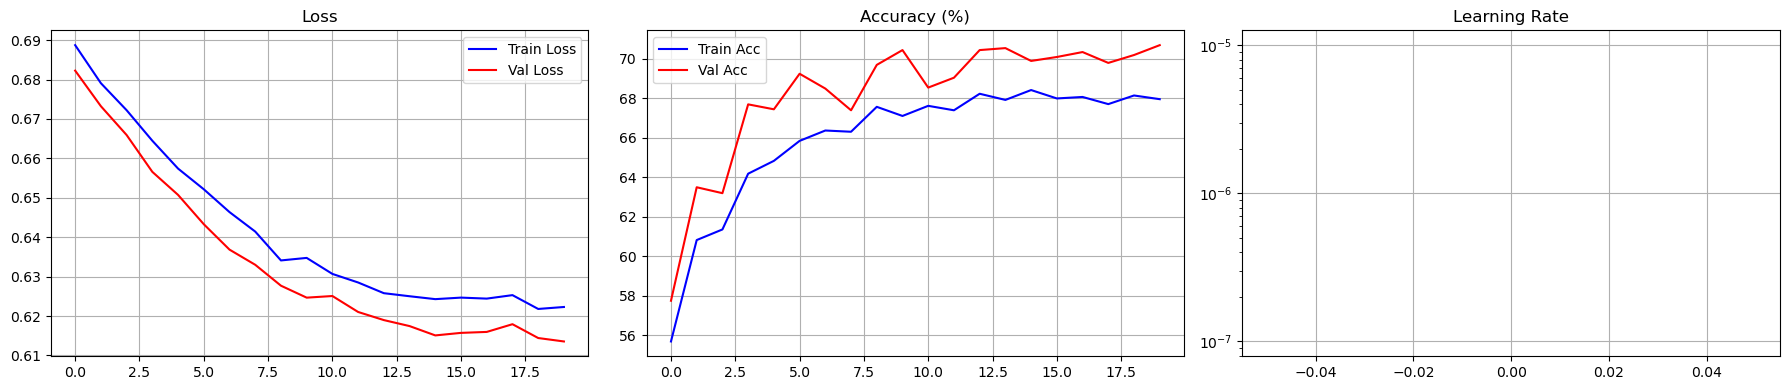

Best Validation Accuracy: 70.70%


MAE_Finetune(
  (encoder): MAEEncoder(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(8, 200, kernel_size=(5, 5), stride=(5, 5))
    )
    (encoder_pos_embed): PositionalEncoding()
    (encoder_blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (Q): Linear(in_features=200, out_features=200, bias=True)
          (K): Linear(in_features=200, out_features=200, bias=True)
          (V): Linear(in_features=200, out_features=200, bias=True)
        )
        (norm2): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=200, out_features=800, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=800, out_features=200, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (encoder_norm): LayerNorm((200,)

In [29]:
# Assuming you already have these:
model = MAE_Finetune(
    pretrained_mae_path="checkpoints/mae_final_20260323_151144.pth",
    num_classes=2,
    unfreeze_blocks=6,
    use_mass_head=True,
)

model = model.to("cuda" if torch.cuda.is_available() else "cpu")

eta_grid = torch.linspace(-1.0, 1.0, 125).unsqueeze(1).repeat(1, 125)  # (125, 125)
phi_grid = torch.linspace(-torch.pi, torch.pi, 125).unsqueeze(0).repeat(125, 1) # (125, 125)

# Convert to device
device = "cuda" if torch.cuda.is_available() else "cpu"
eta_grid = eta_grid.to(device)
phi_grid = phi_grid.to(device)

# Call the training function
model = fineTune_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=20,
    lr=1e-5,
    device=device,
    patience=8,
    use_mass_head=True,
    mass_weight=0.4,          # tune this later if needed
    eta_grid=eta_grid,
    phi_grid=phi_grid,
)